In [1]:
import sys
extra_path = "/root/workdir/vas_research"
if extra_path not in sys.path:
    sys.path.append(extra_path)

In [2]:
import eval

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
torch.cuda.empty_cache()

In [4]:
# чекпоинты обученных моделей. Первый - бейзлайн, второй - со всеми улучшениями
baseline_id = "059259c395e34f71a88cc6a0925953a1"
best_id = "8a8bbaa9405e4c33a450d85b960f5965"

In [5]:
import yaml

eval_config = "configs/eval_vkr.yml"
cfg_net = yaml.load(open(eval_config).read(), Loader=yaml.Loader)
cfg_net.keys()

dict_keys(['eval', 'logging', 'data'])

# Осуществляем инференс первой модели - бейзлайна

In [6]:
cfg_net['eval']['models'] = [baseline_id]

In [7]:
task = eval.create_clearml_task(cfg_net['eval'])

Creating files from configuration
Saved [jupyter_lab_config]: /root/.jupyter/jupyter_lab_config.py
ClearML Task: created new task id=dd3fde96b739493783613a6a3c279491
2025-05-21 20:48:57,875 - clearml.Repository Detection - WARNING - Could not read Jupyter Notebook: No module named 'nbconvert'
2025-05-21 20:48:57,971 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clearml.mlplat.mts-corp.ru/projects/6b412752333e42dcaff6b52b353b75ba/experiments/dd3fde96b739493783613a6a3c279491/output/log


ClearML results page: https://app.clearml.mlplat.mts-corp.ru/projects/6b412752333e42dcaff6b52b353b75ba/experiments/dd3fde96b739493783613a6a3c279491/output/log
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [8]:
eval.eval(cfg_net, task)

Seed set to 1234


2025-05-21 20:49:13,093 - clearml.model - WARNING - Connecting multiple input models with the same name: `model-epoch=09-eer=0.2072`. This might result in the wrong model being used when executing remotely
Create <class 'antispoof.models.wavlm.WavLM'> model with params {'pretrained_path': 'bio/wavlm-base-plus', 's3': 's3://ecsnnvm2.pv.mts.ru:443/data_mlplat_clearml', 'freeze_extractor': True, 'freeze_encoder': True, 'num_heads': 12, 'uniform_layers': False, 'use_asp': False, 'classifier_type': 'simple', 'classifier_params': {'num_classes': 2, 'use_bias': True, 'use_extra_linear': True, 'hidden_dim': 512, 'drop': 0.2, 'use_mean_var': False}}
Try to download folder s3://ecsnnvm2.pv.mts.ru:443/data_mlplat_clearml/bio/wavlm-base-plus
Pretrained path /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus
Model type from pretrained = wavlm
2025-05-21 20:49:14,006 - clearml.model - INFO - Selected model id: fe8f91ffbeb94274835ef61e8950d35c


Some weights of the model checkpoint at /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight

Create loss <class 'antispoof.losses.nll_loss.NLL_Loss'> with params {'loss_weight': 1.0, 'class_weights': [1.0, 1.0]}
Save labels during validation: ['speaker_id', 'system', 'access', 'dataset', 'subset']


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer(limit_test_batches=1.0)` was configured so 100% of the batches will be used..


...

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.8/dist-packages/clearml/utilities/plotlympl/mpltools.py:479: UserWarning:

'linear' x-axis tick spacing not even, ignoring mpl tick formatting.

/usr/local/lib/python3.8/dist-packages/clearml/utilities/plotlympl/mpltools.py:479: UserWarning:

'linear' y-axis tick spacing not even, ignoring mpl tick formatting.



asvspoof2019_LA_16000_- None None 0.048946295037389564 None
too many indices for array: array is 1-dimensional, but 2 were indexed
Testing DataLoader 0: 100%|██████████| 36180/36180 [2:27:38<00:00,  4.08it/s]

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



NameError: name 'task' is not defined

<Figure size 640x480 with 0 Axes>

# Инференс второй модели - лучший эксперимент

In [12]:
cfg_net['eval']['models'] = [best_id]
cfg_net['eval']['trainer']['limit_test_batches'] = 0.1

In [10]:
task = eval.create_clearml_task(cfg_net['eval'])

In [13]:
eval.eval(cfg_net, task)

Seed set to 1234


Create <class 'antispoof.models.wavlm.WavLM'> model with params {'pretrained_path': 'bio/wavlm-base-plus', 's3': 's3://ecsnnvm2.pv.mts.ru:443/data_mlplat_clearml', 'freeze_extractor': True, 'freeze_encoder': False, 'num_heads': 12, 'uniform_layers': False, 'use_asp': False, 'classifier_type': 'simple', 'classifier_params': {'num_classes': 2, 'use_bias': True, 'use_extra_linear': True, 'hidden_dim': 512, 'drop': 0.2, 'use_mean_var': False}}
Try to download folder s3://ecsnnvm2.pv.mts.ru:443/data_mlplat_clearml/bio/wavlm-base-plus
Pretrained path /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus
Model type from pretrained = wavlm


Some weights of the model checkpoint at /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at /mnt/nfs/clearml-lib/.clearml/cache/storage_manager/global/bio/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight

Create loss <class 'antispoof.losses.nll_loss.NLL_Loss'> with params {'loss_weight': 1.0, 'class_weights': [1.0, 1.0]}
Save labels during validation: ['speaker_id', 'system', 'access', 'dataset', 'subset']


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


...

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.8/dist-packages/clearml/utilities/plotlympl/mpltools.py:479: UserWarning:

'linear' x-axis tick spacing not even, ignoring mpl tick formatting.

/usr/local/lib/python3.8/dist-packages/clearml/utilities/plotlympl/mpltools.py:479: UserWarning:

'linear' y-axis tick spacing not even, ignoring mpl tick formatting.



asvspoof2019_LA_16000_- None None 0.0012886597938144284 None
too many indices for array: array is 1-dimensional, but 2 were indexed
Testing DataLoader 0: 100%|██████████| 3618/3618 [14:19<00:00,  4.21it/s]

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



NameError: name 'task' is not defined

<Figure size 640x480 with 0 Axes>

In [39]:
task.close()

# Построение метрик

In [14]:
import csv
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import json
import pickle

In [15]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, det_curve
import matplotlib.colors as mcolors
from sklearn.metrics import DetCurveDisplay

In [17]:
def calc_eer(scores: np.array, targets: np.array, mask=None):
    '''
    Calculates EER
    Return eer and threshold, fpr, tpr, thresholds
    '''
    scores = np.copy(scores)
    targets = np.copy(targets)
    if mask is not None:
        mask = np.array(mask)
        scores = scores[mask]
        targets = targets[mask]
    fpr, tpr, thresholds = roc_curve(targets, scores, pos_label=1)

    # for 1 class data sampling
    if len(set(targets)) == 1:
        return None, None, None, None, None
    
    eer = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    return eer, float(thresh), fpr, 1 - tpr, thresholds

## Используем файлы со скорами обоих моделей после инференса

In [20]:
filelist = "filelists/ssl_research_v1.tsv"
scores = [
    (1, 'results/21_05_2025/c3e22d78567fe9a23c2d5dd6747bfda2.model-epoch=09-eer=0.2072/20:49/score.tsv'),
    (2, 'results/22_05_2025/d025b11c598d5d9d7d53961064f716c4.model-epoch=09-eer=0.0798/06:08/score.tsv'),
]

###  Подгружаем разметку

In [25]:
filelist = pd.read_csv(filelist, delimiter='\t')
filelist = filelist.drop_duplicates(subset='wav_path', keep="first")

In [26]:
filelist.head()

,wav_path,set,access,label,wave_sr,duration,dataset,subset
0,ds_8ef67b88bced4dc38eb5c1049086afc4/ASVspoof20...,train,-,genuine,16000,5.414062,asvspoof2019,LA
1,ds_8ef67b88bced4dc38eb5c1049086afc4/ASVspoof20...,train,-,genuine,16000,3.278625,asvspoof2019,LA
2,ds_8ef67b88bced4dc38eb5c1049086afc4/ASVspoof20...,train,-,genuine,16000,3.279625,asvspoof2019,LA
3,ds_8ef67b88bced4dc38eb5c1049086afc4/ASVspoof20...,train,-,genuine,16000,5.501313,asvspoof2019,LA
4,ds_8ef67b88bced4dc38eb5c1049086afc4/ASVspoof20...,train,-,genuine,16000,4.386750,asvspoof2019,LA


In [27]:
filelist.groupby(by='dataset', as_index=False)['wav_path'].nunique()

,dataset,wav_path
0,asvspoof2019,121461
1,asvspoof2021,682104
2,habla,82986
3,inthewild,31974


### Грузим скоры бейзлайна и строим метрики

In [28]:
scores_baseline = scores[0][1]
scores_df = pd.read_csv(scores_baseline, delimiter='\t', names=['wav_path', 'scores'])
print(scores_df.head())
result_df = pd.merge(scores_df, filelist, on='wav_path', how='inner')
if 'target' not in result_df.columns:
        # result = result.drop(columns=['target'])
        result_df.insert(2, "target", [1 if l == 'spoof' else 0 for l in result_df['label']], True)
result_df.head()

                                            wav_path    scores
0  ds_9c84c8af7b5f4369b190b431a5b85711/CycleGAN/C...  0.996214
1  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.983399
2  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.999867
3  ds_ac6dfeb957a74f58a4308a7a8678aad8/13819_proc...  0.999879
4  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.999677


,wav_path,scores,target,set,access,label,wave_sr,duration,dataset,subset
0,ds_9c84c8af7b5f4369b190b431a5b85711/CycleGAN/C...,0.996214,1,test,la,spoof,16000,9.074938,habla,-
1,ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...,0.983399,1,test,la,spoof,16000,7.680000,asvspoof2021,LA
2,ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...,0.999867,1,test,la,spoof,16000,6.734563,asvspoof2021,LA
3,ds_ac6dfeb957a74f58a4308a7a8678aad8/13819_proc...,0.999879,1,test,la,spoof,16000,5.282000,inthewild,-
4,ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...,0.999677,1,test,la,spoof,16000,5.100000,asvspoof2021,LA


### вычисляем общий EER бейзлайна = 0.2038

In [29]:
eer, threshold, fpr, fnr, thresholds = calc_eer(scores=np.array(result_df['scores']), targets=np.array(result_df['target'])) 
eer

0.2038958925383022

### вычисляем EER по датасетам у бейзлайна

In [33]:
datasets = set(filelist.dataset)
result = result_df
for dataset_name in datasets:
    subset = result.loc[(result.dataset == dataset_name) & (result.wave_sr != 8000)]
    metrics = calc_eer(scores=np.array(subset['scores']), targets=np.array(subset['target']))
    if len(subset) > 0:
        print(f"dataset={dataset_name}, count_samples={len(subset)}, eer={metrics[0]:.4f}")

dataset=inthewild, count_samples=31974, eer=0.2765
dataset=asvspoof2021, count_samples=682104, eer=0.1204
dataset=asvspoof2019, count_samples=71237, eer=0.0290
dataset=habla, count_samples=82986, eer=0.2563


### Грузим скоры лучшей модели и строим метрики

In [34]:
scores_best = scores[1][1]
scores_df = pd.read_csv(scores_best, delimiter='\t', names=['wav_path', 'scores'])
print(scores_df.head())
result_df = pd.merge(scores_df, filelist, on='wav_path', how='inner')
if 'target' not in result_df.columns:
        # result = result.drop(columns=['target'])
        result_df.insert(2, "target", [1 if l == 'spoof' else 0 for l in result_df['label']], True)
# result_df.head()

                                            wav_path    scores
0  ds_9c84c8af7b5f4369b190b431a5b85711/CycleGAN/C...  0.997667
1  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.995626
2  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.999289
3  ds_ac6dfeb957a74f58a4308a7a8678aad8/13819_proc...  0.997348
4  ds_959b2bfaebb44d57972080a5c65cfefc/ASVspoof20...  0.999505


### вычисляем общий EER лучшей модели = 0.0876

In [35]:
eer, threshold, fpr, fnr, thresholds = calc_eer(scores=np.array(result_df['scores']), targets=np.array(result_df['target'])) 
eer

0.08767361111142762

### вычисляем EER по датасетам у лучшей модели

In [36]:
datasets = set(filelist.dataset)
result = result_df
for dataset_name in datasets:
    subset = result.loc[(result.dataset == dataset_name) & (result.wave_sr != 8000)]
    metrics = calc_eer(scores=np.array(subset['scores']), targets=np.array(subset['target']))
    if len(subset) > 0:
        print(f"dataset={dataset_name}, count_samples={len(subset)}, eer={metrics[0]:.4f}")

dataset=inthewild, count_samples=3242, eer=0.1618
dataset=asvspoof2021, count_samples=68112, eer=0.0450
dataset=asvspoof2019, count_samples=7226, eer=0.0043
dataset=habla, count_samples=8252, eer=0.0984


### Итоговая таблица метрик

In [42]:
datasets = ['all data', 'inthewild', 'asvspoof2021', 'asvspoof2019', 'habla']
baseline_metrics = [0.2038, 0.2765, 0.1204, 0.0290, 0.2563]
best_model_metrics = [0.0876, 0.1618, 0.0450, 0.0043, 0.0984]
df = pd.DataFrame(data={'dataset': datasets, 'baseline': baseline_metrics, 'best_model': best_model_metrics})
df

,dataset,baseline,best_model
0,all data,0.2038,0.0876
1,inthewild,0.2765,0.1618
2,asvspoof2021,0.1204,0.0450
3,asvspoof2019,0.0290,0.0043
4,habla,0.2563,0.0984


### Выводим сравнительный график DET кривых двух моделей

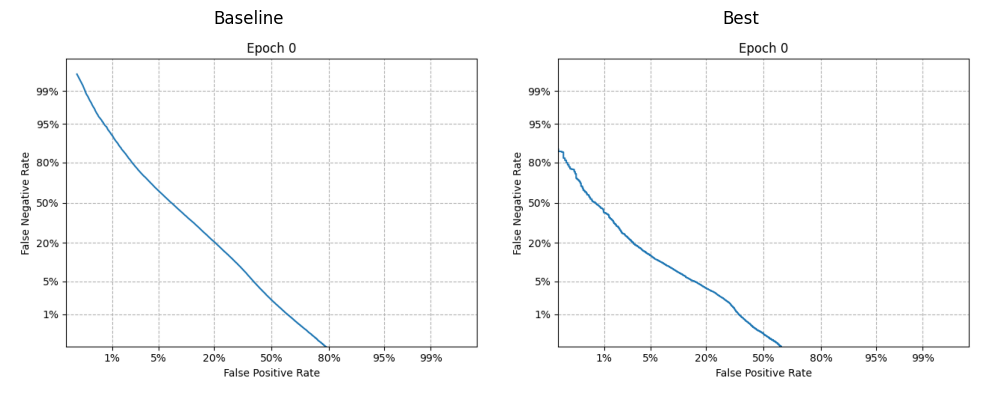

In [37]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
image1 = mpimg.imread('results/21_05_2025/c3e22d78567fe9a23c2d5dd6747bfda2.model-epoch=09-eer=0.2072/20:49/DET curve.png')
image2 = mpimg.imread('results/22_05_2025/d025b11c598d5d9d7d53961064f716c4.model-epoch=09-eer=0.0798/06:08/DET curve.png')

# Create the figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Plot the first image
axes[0].imshow(image1)
axes[0].set_title('Baseline')
axes[0].axis('off')  # Hide axes

# Plot the second image
axes[1].imshow(image2)
axes[1].set_title('Best')
axes[1].axis('off')  # Hide axes

# Adjust layout and display
plt.tight_layout()
plt.show()

### Выводим сравнительный график распределения скоров двух моделей

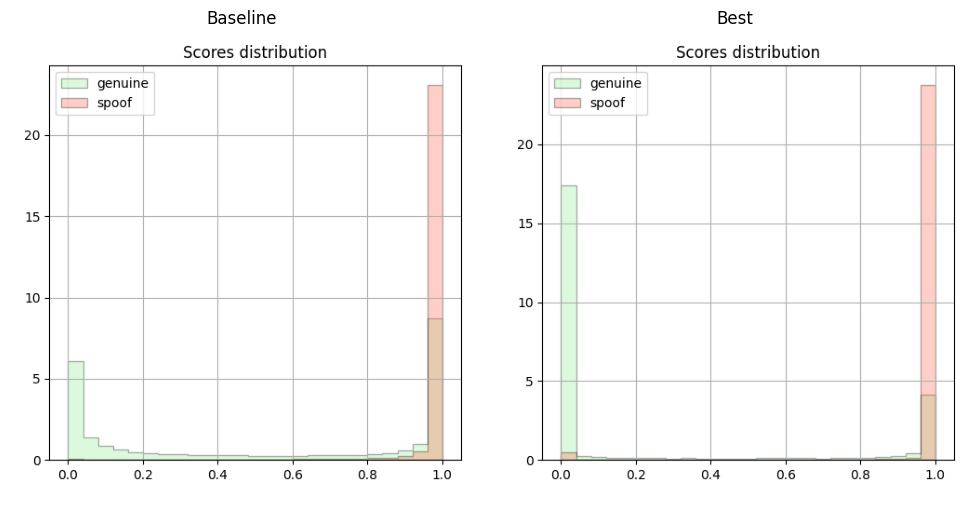

In [38]:
# Load the images
image1 = mpimg.imread('results/21_05_2025/c3e22d78567fe9a23c2d5dd6747bfda2.model-epoch=09-eer=0.2072/20:49/Scores distribution.png')
image2 = mpimg.imread('results/22_05_2025/d025b11c598d5d9d7d53961064f716c4.model-epoch=09-eer=0.0798/06:08/Scores distribution.png')

# Create the figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Plot the first image
axes[0].imshow(image1)
axes[0].set_title('Baseline')
axes[0].axis('off')  # Hide axes

# Plot the second image
axes[1].imshow(image2)
axes[1].set_title('Best')
axes[1].axis('off')  # Hide axes

# Adjust layout and display
plt.tight_layout()
plt.show()